In [34]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Input, DepthwiseConv2D, Conv2D, BatchNormalization,
    Activation, GlobalAveragePooling2D, Dense, Dropout
)
from tensorflow.keras.models import Model

In [35]:
DATASET_PATH = "/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"

classes = ["benign","malignant","normal"]

IMG_SIZE = 128

In [36]:
images = []
labels = []

for c in classes:
    
    path = os.path.join(DATASET_PATH, c)
    
    for img in os.listdir(path):
        
        if "_mask" in img:
            continue
        
        img_path = os.path.join(path, img)
        
        image = cv2.imread(img_path)
        image = cv2.resize(image,(IMG_SIZE,IMG_SIZE))
        image = image / 255.0
        
        images.append(image)
        labels.append(c)

X = np.array(images)
y = np.array(labels)

print("Dataset shape:",X.shape)

Dataset shape: (780, 128, 128, 3)


In [37]:
le = LabelEncoder()

y = le.fit_transform(y)

print("Classes:",le.classes_)

Classes: ['benign' 'malignant' 'normal']


In [38]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [39]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:",X_train.shape)
print("Validation:",X_val.shape)
print("Test:",X_test.shape)

Train: (546, 128, 128, 3)
Validation: (117, 128, 128, 3)
Test: (117, 128, 128, 3)


In [40]:
def depthwise_separable_block(x, filters, strides=1):
    
    # Depthwise Convolution
    x = DepthwiseConv2D(kernel_size=(3,3), strides=strides, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # Pointwise Convolution (1x1)
    x = Conv2D(filters, kernel_size=(1,1), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x


def create_model():

    inputs = Input(shape=(128,128,3))

    # Initial convolution
    x = Conv2D(32,(3,3),padding="same",strides=2)(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # Depthwise Separable Blocks
    x = depthwise_separable_block(x,64)
    x = depthwise_separable_block(x,128,strides=2)
    x = depthwise_separable_block(x,128)
    
    x = depthwise_separable_block(x,256,strides=2)
    x = depthwise_separable_block(x,256)

    x = depthwise_separable_block(x,512,strides=2)
    x = depthwise_separable_block(x,512)

    # Global pooling
    x = GlobalAveragePooling2D()(x)

    # Dense classifier (same as your pipeline)
    x = Dense(256,activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(128,activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    output = Dense(3,activation="softmax")(x)

    model = Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [41]:
model_imbalanced = create_model()

history_imbalanced = model_imbalanced.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=30,
    batch_size=16
)

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 33s 398ms/step - accuracy: 0.3781 - loss: 1.6809 - val_accuracy: 0.2735 - val_loss: 1.1432
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4756 - loss: 1.3766 - val_accuracy: 0.1709 - val_loss: 1.1894
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4957 - loss: 1.2606 - val_accuracy: 0.1709 - val_loss: 1.2507
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5029 - loss: 1.2702 - val_accuracy: 0.1709 - val_loss: 1.2829
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5611 - loss: 1.0898 - val_accuracy: 0.1709 - val_loss: 1.3652
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5420 - loss: 1.1658 - val_accuracy: 0.1709 - val_loss: 1.4157
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5795 - loss: 1.0619 - val_accuracy: 0.1709 - val_loss: 1.4239
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5709 - loss: 1.1232 - val_accuracy: 0.1966 -

In [42]:
y_pred = model_imbalanced.predict(X_test)

y_pred_classes = np.argmax(y_pred,axis=1)

acc1 = accuracy_score(y_test,y_pred_classes)
prec1 = precision_score(y_test,y_pred_classes,average="weighted")
rec1 = recall_score(y_test,y_pred_classes,average="weighted")
f11 = f1_score(y_test,y_pred_classes,average="weighted")

print("IMBALANCED MODEL RESULTS")

print("Accuracy:",acc1)
print("Precision:",prec1)
print("Recall:",rec1)
print("F1 Score:",f11)

print(classification_report(y_test,y_pred_classes))

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 699ms/step
IMBALANCED MODEL RESULTS
Accuracy: 0.39316239316239315
Precision: 0.5292832167832168
Recall: 0.39316239316239315
F1 Score: 0.40750237416904084
              precision    recall  f1-score   support

           0       0.67      0.30      0.42        66
           1       0.44      0.45      0.44        31
           2       0.22      0.60      0.32        20

    accuracy                           0.39       117
   macro avg       0.44      0.45      0.39       117
weighted avg       0.53      0.39      0.41       117



In [43]:
X_train_flat = X_train.reshape(len(X_train),-1)

sm = SMOTE(random_state=42)

X_smote,y_smote = sm.fit_resample(X_train_flat,y_train)

print("Before SMOTE:",np.bincount(y_train))
print("After SMOTE:",np.bincount(y_smote))

Before SMOTE: [306 147  93]
After SMOTE: [306 306 306]


In [44]:
X_smote = X_smote.reshape(-1,128,128,3)

In [45]:
model_smote = create_model()

history_smote = model_smote.fit(
    X_smote,
    y_smote,
    validation_data=(X_val,y_val),
    epochs=30,
    batch_size=16
)

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 34s 268ms/step - accuracy: 0.4059 - loss: 1.4717 - val_accuracy: 0.2735 - val_loss: 1.2561
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5134 - loss: 1.2368 - val_accuracy: 0.1709 - val_loss: 1.5007
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5639 - loss: 1.0374 - val_accuracy: 0.1709 - val_loss: 1.9540
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6087 - loss: 0.9452 - val_accuracy: 0.1709 - val_loss: 2.6643
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6099 - loss: 0.9438 - val_accuracy: 0.1709 - val_loss: 3.4399
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7193 - loss: 0.7544 - val_accuracy: 0.1709 - val_loss: 4.0438
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7404 - loss: 0.6646 - val_accuracy: 0.1709 - val_loss: 4.7312
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7917 - loss: 0.5512 - val_accuracy: 0.1709 -

In [46]:
y_pred = model_smote.predict(X_test)

y_pred_classes = np.argmax(y_pred,axis=1)

acc2 = accuracy_score(y_test,y_pred_classes)
prec2 = precision_score(y_test,y_pred_classes,average="weighted")
rec2 = recall_score(y_test,y_pred_classes,average="weighted")
f12 = f1_score(y_test,y_pred_classes,average="weighted")

print("SMOTE MODEL RESULTS")

print("Accuracy:",acc2)
print("Precision:",prec2)
print("Recall:",rec2)
print("F1 Score:",f12)

print(classification_report(y_test,y_pred_classes))

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 710ms/step
SMOTE MODEL RESULTS
Accuracy: 0.5726495726495726
Precision: 0.5543408158792775
Recall: 0.5726495726495726
F1 Score: 0.5506873484865539
              precision    recall  f1-score   support

           0       0.68      0.67      0.67        66
           1       0.47      0.68      0.55        31
           2       0.29      0.10      0.15        20

    accuracy                           0.57       117
   macro avg       0.48      0.48      0.46       117
weighted avg       0.55      0.57      0.55       117



In [47]:
datagen = ImageDataGenerator(

    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,

    zoom_range=0.1,
    horizontal_flip=True,

    fill_mode="nearest"
)

datagen.fit(X_train)

In [48]:

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5947712418300654), np.int64(1): np.float64(1.2380952380952381), np.int64(2): np.float64(1.956989247311828)}


In [49]:


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=4,
    min_lr=1e-6
)

In [50]:
model_aug = create_model()

history_aug = model_aug.fit(

    datagen.flow(X_train, y_train, batch_size=16),

    validation_data=(X_val, y_val),

    epochs=30,

    class_weight=class_weights,

    callbacks=[early_stop, reduce_lr]

)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


35/35 ━━━━━━━━━━━━━━━━━━━━ 35s 470ms/step - accuracy: 0.3530 - loss: 1.7550 - val_accuracy: 0.2735 - val_loss: 1.1176 - learning_rate: 1.0000e-04
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.3777 - loss: 1.5048 - val_accuracy: 0.2735 - val_loss: 1.1411 - learning_rate: 1.0000e-04
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.3773 - loss: 1.6009 - val_accuracy: 0.2735 - val_loss: 1.1339 - learning_rate: 1.0000e-04
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.3854 - loss: 1.4675 - val_accuracy: 0.2735 - val_loss: 1.1103 - learning_rate: 1.0000e-04
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.4688 - loss: 1.4157 - val_accuracy: 0.2735 - val_loss: 1.0992 - learning_rate: 1.0000e-04
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.4205 - loss: 1.4965 - val_accuracy: 0.5556 - val_loss: 1.0673 - learning_rate: 1.0000e-04
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.4370 - loss: 1

In [51]:
y_pred = model_aug.predict(X_test)

y_pred_classes = np.argmax(y_pred,axis=1)

acc3 = accuracy_score(y_test,y_pred_classes)
prec3 = precision_score(y_test,y_pred_classes,average="weighted")
rec3 = recall_score(y_test,y_pred_classes,average="weighted")
f13 = f1_score(y_test,y_pred_classes,average="weighted")

print("AUGMENTATION MODEL RESULTS")

print("Accuracy:",acc3)
print("Precision:",prec3)
print("Recall:",rec3)
print("F1 Score:",f13)

print(classification_report(y_test,y_pred_classes))

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 711ms/step
AUGMENTATION MODEL RESULTS
Accuracy: 0.5641025641025641
Precision: 0.31821170282708744
Recall: 0.5641025641025641
F1 Score: 0.40689365279529216
              precision    recall  f1-score   support

           0       0.56      1.00      0.72        66
           1       0.00      0.00      0.00        31
           2       0.00      0.00      0.00        20

    accuracy                           0.56       117
   macro avg       0.19      0.33      0.24       117
weighted avg       0.32      0.56      0.41       117



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [52]:
print("\nFINAL MODEL COMPARISON")

print("\nMobileNetV2 (Imbalanced)")
print("Accuracy:",acc1)
print("Precision:",prec1)
print("Recall:",rec1)
print("F1:",f11)

print("\nMobileNetV2 + SMOTE")
print("Accuracy:",acc2)
print("Precision:",prec2)
print("Recall:",rec2)
print("F1:",f12)

print("\nMobileNetV2 + Augmentation")
print("Accuracy:",acc3)
print("Precision:",prec3)
print("Recall:",rec3)
print("F1:",f13)


FINAL MODEL COMPARISON

MobileNetV2 (Imbalanced)
Accuracy: 0.39316239316239315
Precision: 0.5292832167832168
Recall: 0.39316239316239315
F1: 0.40750237416904084

MobileNetV2 + SMOTE
Accuracy: 0.5726495726495726
Precision: 0.5543408158792775
Recall: 0.5726495726495726
F1: 0.5506873484865539

MobileNetV2 + Augmentation
Accuracy: 0.5641025641025641
Precision: 0.31821170282708744
Recall: 0.5641025641025641
F1: 0.40689365279529216


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


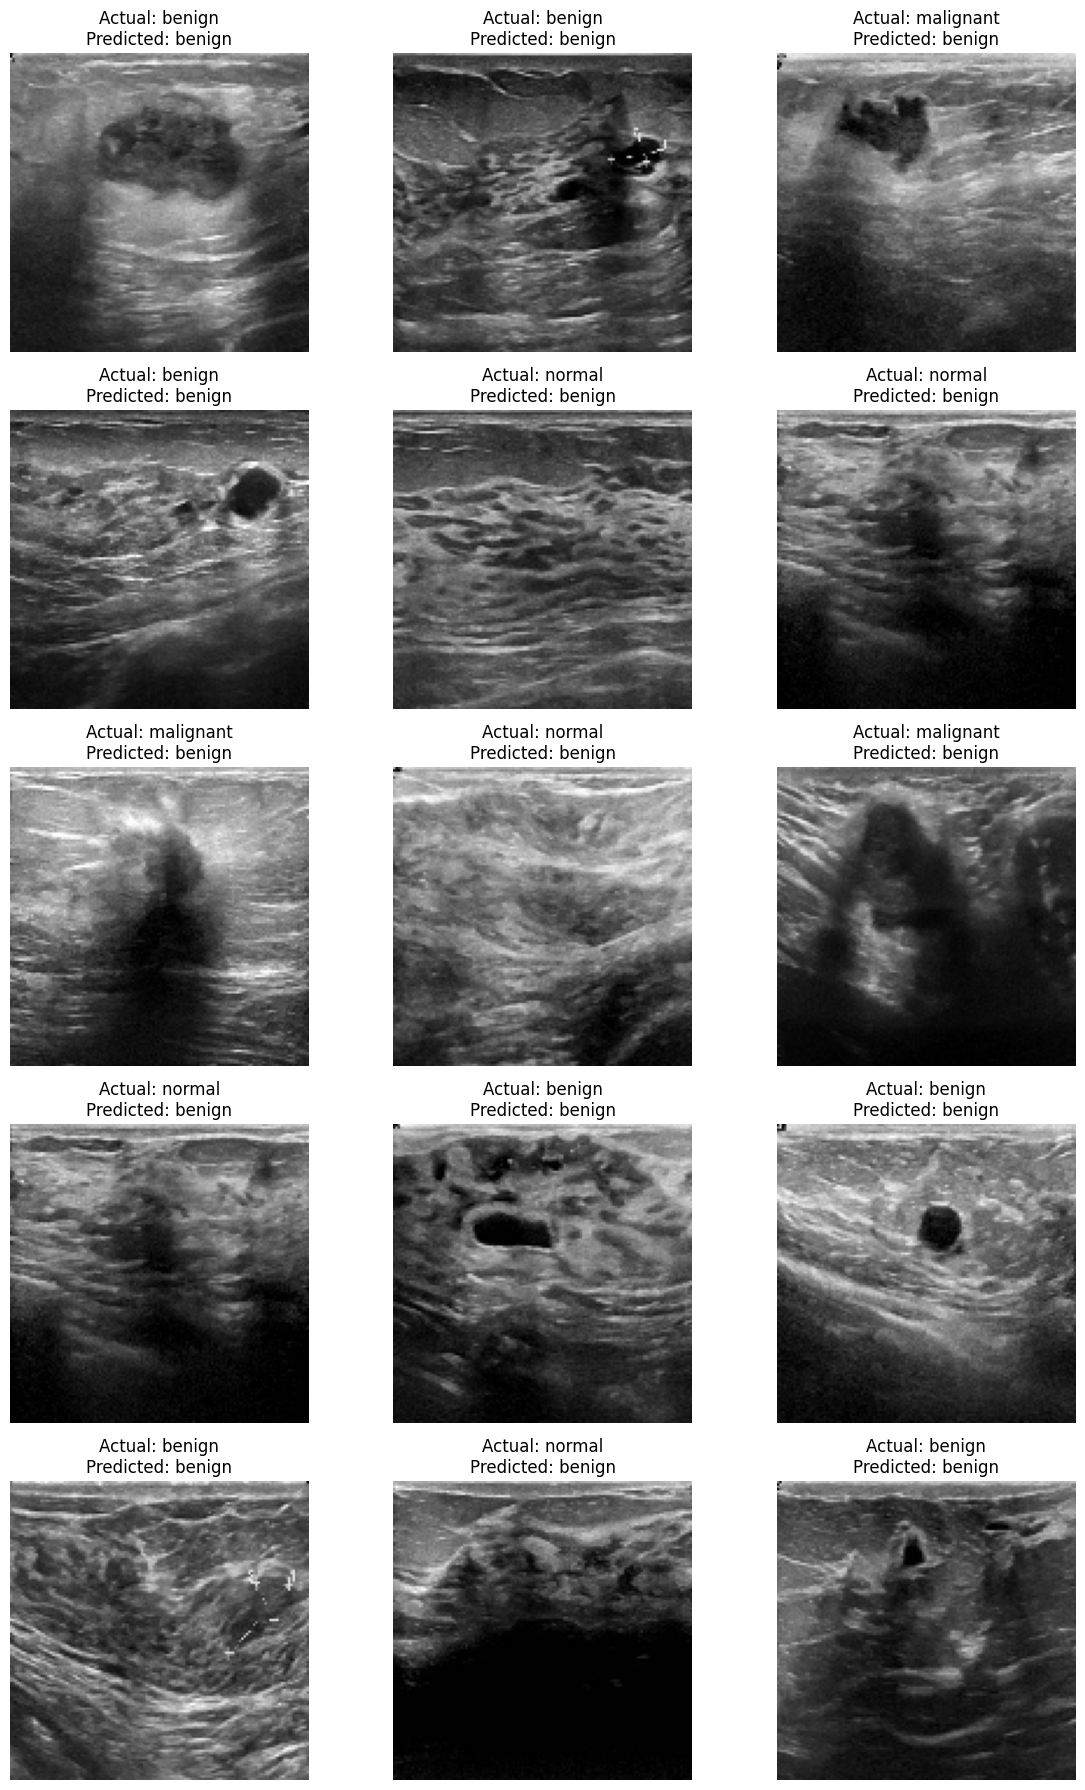

In [53]:
num_images = 15

indices = np.random.choice(len(X_test),num_images)

sample_images = X_test[indices]
sample_labels = y_test[indices]

predictions = model_aug.predict(sample_images)

pred_classes = np.argmax(predictions,axis=1)

plt.figure(figsize=(12,18))

for i in range(num_images):
    
    ax = plt.subplot(5,3,i+1)
    
    ax.axis("off")
    
    actual = le.classes_[sample_labels[i]]
    predicted = le.classes_[pred_classes[i]]
    
    ax.set_title(f"Actual: {actual}\nPredicted: {predicted}")
    
    plt.imshow(sample_images[i])

plt.tight_layout()

plt.show()